In [40]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import glob
import os
import re
from tensorflow.keras import layers, models


In [41]:
threshold_offset = 80
num_thresholds = 3
random_thresholds = sorted(
    np.random.uniform(low=threshold_offset, high=2000.0, size=num_thresholds)
)

random_thresholds

[436.946107756394, 910.9511983824322, 1300.372004174127]

In [42]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [43]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")



In [44]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

# tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr")

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [45]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/TFR_files/2t_N_0.0mu_80.0sig/TFR_val/metadata.json


[99.17029747 24.79370923  6.53245764  1.89031215]


In [46]:
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr"
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig"

# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr_4p0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf0.0_ThL0.0_ThH120.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf400.0_ThL400.0_ThH2200.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf2000.0_ThL2000.0_ThH2200.0'



models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf80.0_ThL80.0_ThH2200.0'


In [47]:
os.listdir(models_base_dir)

['Transformer_model-e1be0aba-checkpoints',
 'Transformer_model-9c6e9ccd-checkpoints',
 'Transformer_model-31ff8483-checkpoints',
 'Transformer_model-c5e960d0-checkpoints',
 'Transformer_model-d1758406-checkpoints',
 'Transformer_model-952ee1a6-checkpoints',
 'Transformer_model-7357cad7-checkpoints',
 'Transformer_model-5345f081-checkpoints',
 'Transformer_model-706bf351-checkpoints',
 'Transformer_model-19a9bedf-checkpoints',
 'Transformer_model-459bf42c-checkpoints',
 'Transformer_model-7fa67cd1-checkpoints',
 'Transformer_model-17059ee3-checkpoints',
 'Transformer_model-f64df353-checkpoints',
 'Transformer_model-5666bba9-checkpoints',
 'Transformer_model-1caf997f-checkpoints',
 'Transformer_model-25232f92-checkpoints',
 'Transformer_model-fde5c5aa-checkpoints',
 'Transformer_model-a144c93e-checkpoints',
 'Transformer_model-04eee49f-checkpoints',
 'Transformer_model-cf894f3b-checkpoints',
 'Transformer_model-fa9a78bf-checkpoints',
 'Transformer_model-e4bdcd37-checkpoints',
 'Transform

In [48]:
dirs = glob.glob(os.path.join(models_base_dir, "Transformer_model-*-checkpoints"))
fingerprint_list = []
for d in dirs:
    m = re.search(r"Transformer_model-([a-f0-9]+)-checkpoints$", os.path.basename(d))
    if m:
        fingerprint_list.append(m.group(1))

print(fingerprint_list)

['e1be0aba', '9c6e9ccd', '31ff8483', 'c5e960d0', 'd1758406', '952ee1a6', '7357cad7', '5345f081', '706bf351', '19a9bedf', '459bf42c', '7fa67cd1', '17059ee3', 'f64df353', '5666bba9', '1caf997f', '25232f92', 'fde5c5aa', 'a144c93e', '04eee49f', 'cf894f3b', 'fa9a78bf', 'e4bdcd37', '8b7db1ce', '86f04000', 'ca5018ba', '6c0bcfdb']


In [49]:
import os
import pandas as pd

def get_first_mtime(path):
    """Return earliest modification time (approx creation) under path."""
    mtimes = []
    for root, _, files in os.walk(path):
        for f in files:
            full_path = os.path.join(root, f)
            try:
                mtimes.append(os.path.getmtime(full_path))
            except FileNotFoundError:
                continue
    if not mtimes:
        return None
    return min(mtimes)

all_results = []

for fingerprint in fingerprint_list:
    try:
        base_dir = os.path.join(models_base_dir, f"Transformer_model-{fingerprint}-checkpoints")
        checkpoints_dir = os.path.join(base_dir, "checkpoints")
        training_log = os.path.join(base_dir, "training_log.csv")
        quantizer_log = os.path.join(base_dir, "soft_quantizer_state_log.csv")
    
        # --- Load logs ---
        training_df = pd.read_csv(training_log)
        quant_df = pd.read_csv(quantizer_log)
    
        if len(training_df) != len(quant_df):
            raise ValueError(
                f"[{fingerprint}] Mismatch: training_log={len(training_df)}, quantizer_log={len(quant_df)}"
            )
    
        # --- Best checkpoint selection ---
        checkpoint_files = sorted(
            f for f in os.listdir(checkpoints_dir) if f.endswith((".hdf5", ".h5"))
        )
        checkpoint_files = [os.path.join(checkpoints_dir, f) for f in checkpoint_files]
    
        if not checkpoint_files:
            raise FileNotFoundError(f"[{fingerprint}] No checkpoint files found in {checkpoints_dir}")
    
        best_ckpt = max(checkpoint_files, key=lambda f: extract_val_metric(os.path.basename(f)))
        best_val = extract_val_metric(os.path.basename(best_ckpt))
    
        print(f"[{fingerprint}] Best checkpoint: {os.path.basename(best_ckpt)} (val={best_val:.4f})")
    
        # --- Merge training & quantizer logs ---
        df = training_df.copy()
        df["fingerprint"] = fingerprint
        df["best_val_metric"] = best_val
    
        for col in quant_df.columns:
            df[f"quantizer_{col}"] = quant_df[col].values
    
        # First modification timestamp
        first_mtime = get_first_mtime(base_dir)
        df["first_modified"] = pd.to_datetime(first_mtime, unit="s") if first_mtime else None
    
        all_results.append(df)
    except:
        continue

# === Final aggregation ===
final_df = pd.concat(all_results, ignore_index=True)

print("Final aggregated DataFrame shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())


[e1be0aba] Best checkpoint: weights.919-t-44374.38-v-46010.39.hdf5 (val=46010.3900)
[9c6e9ccd] Best checkpoint: weights.01-t102990.85-v102835.76.hdf5 (val=-inf)
[31ff8483] Best checkpoint: weights.959-t-27216.46-v-28661.39.hdf5 (val=28661.3900)
[c5e960d0] Best checkpoint: weights.1000-t-30665.14-v-32052.01.hdf5 (val=32052.0100)
[d1758406] Best checkpoint: weights.01-t102989.85-v102835.76.hdf5 (val=-inf)
[952ee1a6] Best checkpoint: weights.986-t-29383.04-v-30844.05.hdf5 (val=30844.0500)
[7357cad7] Best checkpoint: weights.01-t102990.81-v102835.76.hdf5 (val=-inf)
[5345f081] Best checkpoint: weights.01-t102990.74-v102835.76.hdf5 (val=-inf)
[706bf351] Best checkpoint: weights.01-t102990.66-v102835.76.hdf5 (val=-inf)
[19a9bedf] Best checkpoint: weights.992-t-44298.12-v-46165.74.hdf5 (val=46165.7400)
[459bf42c] Best checkpoint: weights.1000-t-44807.69-v-46789.20.hdf5 (val=46789.2000)
[7fa67cd1] Best checkpoint: weights.993-t-44834.54-v-46698.74.hdf5 (val=46698.7400)
[17059ee3] Best checkpoin

In [50]:
def unnormalize_thresholds(norm_thresh, mu, sigma, s_pos, s_neg):
    norm_thresh = np.asarray(norm_thresh)
    scaled_back = np.where(norm_thresh > 0, norm_thresh * s_pos, norm_thresh * s_neg)
    log_vals = scaled_back * sigma + mu
    raw_charges = np.sign(log_vals) * (2 ** np.abs(log_vals) - 1)

    return raw_charges

In [51]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[0]

    # Normalized thresholds
    norm_vec = [
        last['quantizer_threshold_0'],
        last['quantizer_threshold_1'],
        last['quantizer_threshold_2']
    ]

    charge_vec = norm_vec
    
    # Fetch timestamp string
    first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

    # Print output
    print(f"Created:\t{first_str})")
    print(f"  Fingeprint: {fingerprint}")
    print(f"  Last val_loss:\t{last['val_loss']:.2f}")
    print(f"  Norm thresholds:\t[{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
    print(f"  Raw thresholds :\t[{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
    print()


Created:	2025-11-10 02:21:40)
  Fingeprint: 1caf997f
  Last val_loss:	12379.65
  Norm thresholds:	[510.56, 1129.62, 1321.67]
  Raw thresholds :	[510.56, 1129.62, 1321.67]

Created:	2025-11-10 04:55:02)
  Fingeprint: cf894f3b
  Last val_loss:	13414.24
  Norm thresholds:	[257.89, 523.49, 621.79]
  Raw thresholds :	[257.89, 523.49, 621.79]

Created:	2025-11-10 07:29:43)
  Fingeprint: 6c0bcfdb
  Last val_loss:	18347.20
  Norm thresholds:	[254.10, 1467.18, 2016.34]
  Raw thresholds :	[254.10, 1467.18, 2016.34]

Created:	2025-11-10 10:05:37)
  Fingeprint: 7357cad7
  Last val_loss:	102835.76
  Norm thresholds:	[225.91, 1331.97, 1349.18]
  Raw thresholds :	[225.91, 1331.97, 1349.18]

Created:	2025-11-10 10:06:39)
  Fingeprint: 17059ee3
  Last val_loss:	102835.76
  Norm thresholds:	[874.28, 1061.71, 2110.16]
  Raw thresholds :	[874.28, 1061.71, 2110.16]

Created:	2025-11-10 10:07:42)
  Fingeprint: 706bf351
  Last val_loss:	102835.76
  Norm thresholds:	[1218.50, 1481.88, 1688.13]
  Raw threshold

In [52]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[-1]

    # Normalized thresholds
    norm_vec = [
        last['quantizer_threshold_0'],
        last['quantizer_threshold_1'],
        last['quantizer_threshold_2']
    ]

    charge_vec = norm_vec
    
    # # Map to raw charge space
    # charge_vec = unnormalize_thresholds(
    #     norm_vec,
    #     mu=test_generator.dataset_mean[0],
    #     sigma=test_generator.dataset_std[0],
    #     s_pos=test_generator.norm_factor_pos,
    #     s_neg=test_generator.norm_factor_neg
    # )    
    
    # Fetch timestamp string
    first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

    # Print output
    print(f"Created:\t{first_str})")
    print(f"  Fingeprint: {fingerprint}")
    print(f"  Last val_loss:\t{last['val_loss']:.2f}")
    print(f"  Norm thresholds:\t[{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
    print(f"  Raw thresholds :\t[{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
    print()


Created:	2025-11-10 02:21:40)
  Fingeprint: 1caf997f
  Last val_loss:	-31088.19
  Norm thresholds:	[245.09, 669.85, 1656.50]
  Raw thresholds :	[245.09, 669.85, 1656.50]

Created:	2025-11-10 04:55:02)
  Fingeprint: cf894f3b
  Last val_loss:	-46502.56
  Norm thresholds:	[244.99, 656.69, 1634.74]
  Raw thresholds :	[244.99, 656.69, 1634.74]

Created:	2025-11-10 07:29:43)
  Fingeprint: 6c0bcfdb
  Last val_loss:	-46797.20
  Norm thresholds:	[247.92, 668.25, 1626.19]
  Raw thresholds :	[247.92, 668.25, 1626.19]

Created:	2025-11-10 10:05:37)
  Fingeprint: 7357cad7
  Last val_loss:	102835.76
  Norm thresholds:	[225.91, 1331.97, 1349.18]
  Raw thresholds :	[225.91, 1331.97, 1349.18]

Created:	2025-11-10 10:06:39)
  Fingeprint: 17059ee3
  Last val_loss:	102835.76
  Norm thresholds:	[874.27, 1061.70, 2110.14]
  Raw thresholds :	[874.27, 1061.70, 2110.14]

Created:	2025-11-10 10:07:42)
  Fingeprint: 706bf351
  Last val_loss:	102835.76
  Norm thresholds:	[1218.48, 1481.87, 1688.11]
  Raw threshol

In [53]:
# Get unique fingerprints sorted by first_modified timestamp
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)


In [54]:
last_rows = (
    final_df.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)
print(len(last_rows))
# Filter out bad val_loss
masks =  (
    (last_rows["val_loss"] < -20000)
    # & (last_rows.index != "ca5018ba" )
)

last_rows = last_rows[masks]

# last_rows = last_rows[last_rows["epoch"] == 999]
print(len(last_rows))


27
20


In [55]:
# Get unique fingerprints sorted by creation time
sorted_fps = (
    final_df[["fingerprint", "first_modified"]]
    .drop_duplicates()
    .sort_values("first_modified")
    .fingerprint
    .tolist()
)

# Get the last row for each fingerprint (by epoch)
last_rows = (
    final_df.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
    .set_index("fingerprint")
)

# Loop in sorted order
for fingerprint in sorted_fps:
    df = final_df[final_df["fingerprint"] == fingerprint].sort_values("epoch")
    last = df.iloc[-1]

    val_loss = last["val_loss"]

    # Filter based on val_loss threshold
    if val_loss < -20000:
        norm_vec = [
            last['quantizer_threshold_0'],
            last['quantizer_threshold_1'],
            last['quantizer_threshold_2']
        ]

        # (Assuming raw thresholds = normalized thresholds; change if needed)
        charge_vec = norm_vec

        first_str = df["first_modified"].iloc[0].strftime("%Y-%m-%d %H:%M:%S")

        print(f"Created:         {first_str}")
        print(f"  Fingerprint:   {fingerprint}")
        print(f"  Last val_loss: {val_loss:.2f}")
        print(f"  Norm thresholds: [{norm_vec[0]:.2f}, {norm_vec[1]:.2f}, {norm_vec[2]:.2f}]")
        print(f"  Raw thresholds : [{charge_vec[0]:.2f}, {charge_vec[1]:.2f}, {charge_vec[2]:.2f}]")
        print()


Created:         2025-11-10 02:21:40
  Fingerprint:   1caf997f
  Last val_loss: -31088.19
  Norm thresholds: [245.09, 669.85, 1656.50]
  Raw thresholds : [245.09, 669.85, 1656.50]

Created:         2025-11-10 04:55:02
  Fingerprint:   cf894f3b
  Last val_loss: -46502.56
  Norm thresholds: [244.99, 656.69, 1634.74]
  Raw thresholds : [244.99, 656.69, 1634.74]

Created:         2025-11-10 07:29:43
  Fingerprint:   6c0bcfdb
  Last val_loss: -46797.20
  Norm thresholds: [247.92, 668.25, 1626.19]
  Raw thresholds : [247.92, 668.25, 1626.19]

Created:         2025-11-10 10:08:45
  Fingerprint:   31ff8483
  Last val_loss: -28510.45
  Norm thresholds: [258.96, 681.09, 1736.72]
  Raw thresholds : [258.96, 681.09, 1736.72]

Created:         2025-11-10 12:51:36
  Fingerprint:   f64df353
  Last val_loss: -31094.68
  Norm thresholds: [242.04, 666.18, 1660.09]
  Raw thresholds : [242.04, 666.18, 1660.09]

Created:         2025-11-10 15:35:54
  Fingerprint:   7fa67cd1
  Last val_loss: -46554.81
  Nor

In [56]:
# Sort by epoch ascending
df_sorted = final_df.sort_values(["fingerprint", "epoch"])

# Get last epoch per fingerprint
last_rows = df_sorted.groupby("fingerprint", as_index=False).tail(1)

# --- Filter conditions ---
# (a) Completed full training (e.g., epoch == 999 or == 1000)
last_rows = last_rows[last_rows["epoch"] >= 999]

# (b) Filter based on loss sanity (e.g., discard exploded values)
# last_rows = last_rows[last_rows["val_loss"] < -20000]

masks =  (
    (last_rows["val_loss"] < -20000)
    & (last_rows["fingerprint"] != "ca5018ba" )
)

last_rows = last_rows[masks]

print(f"Selected {len(last_rows)} runs after filtering.")


Selected 18 runs after filtering.


In [57]:
df_sorted.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'first_modified'],
      dtype='object')

In [58]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]


In [59]:
# Convert normalized thresholds → charge thresholds for each row
# for i in range(3):
#     df_filtered[f"charge_threshold_{i}"] = df_filtered.apply(
#         lambda row: unnormalize_thresholds(
#             [row[f"quantizer_threshold_{i}"]],
#             mu=test_generator.dataset_mean[0],
#             sigma=test_generator.dataset_std[0],
#             s_pos=test_generator.norm_factor_pos,
#             s_neg=test_generator.norm_factor_neg
#         )[0],
#         axis=1
#     )
# Safe assignment to avoid SettingWithCopyWarning
df_filtered = df_filtered.copy()  # ← this removes the ambiguity

for i in range(3):
    df_filtered[f"charge_threshold_{i}"] = df_filtered[f"quantizer_threshold_{i}"]


In [60]:
threshold_cols = [
    "quantizer_threshold_0",
    "quantizer_threshold_1",
    "quantizer_threshold_2"
]
colors = ["C0", "C1", "C2"] 



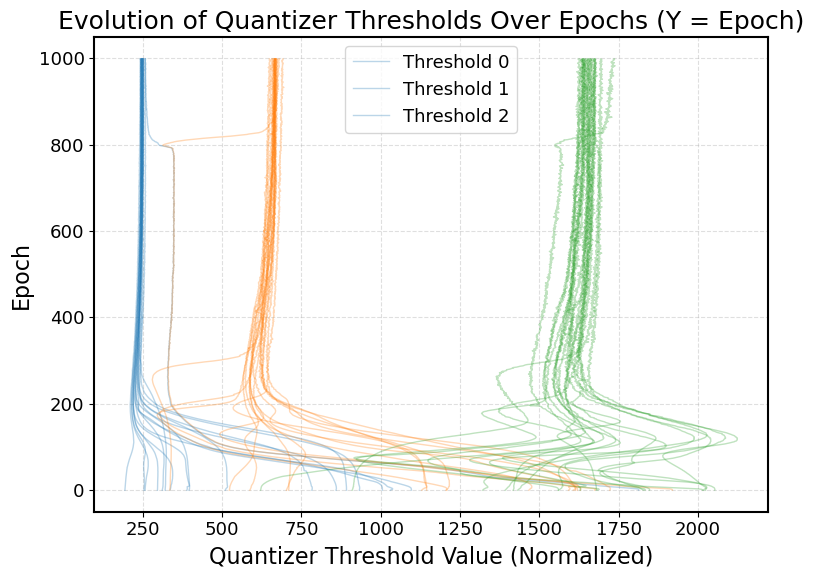

In [61]:
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])]

plt.figure(figsize=(8, 6))

for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Quantizer Threshold Value (Normalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds Over Epochs (Y = Epoch)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(len(threshold_cols))], loc="best")
plt.tight_layout()
plt.show()


In [62]:
df_filtered.keys()

Index(['epoch', 'loss', 'val_loss', 'fingerprint', 'best_val_metric',
       'quantizer_epoch', 'quantizer_k', 'quantizer_level_0',
       'quantizer_level_1', 'quantizer_level_2', 'quantizer_level_3',
       'quantizer_threshold_0', 'quantizer_threshold_1',
       'quantizer_threshold_2', 'first_modified'],
      dtype='object')

In [63]:
# --- Step 1: filter once, and keep this reference ---
df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])].copy()
for i in range(3):
    df_sorted[f"charge_threshold_{i}"] = df_sorted[f"quantizer_threshold_{i}"]

df_filtered = df_sorted[df_sorted["fingerprint"].isin(last_rows["fingerprint"])].copy()
for i in range(3):
    df_sorted[f"charge_threshold_{i}"] = df_sorted[f"quantizer_threshold_{i}"]
    
# # --- Step 2: add charge thresholds to this same object ---
# for i in range(3):
#     df_filtered.loc[:, f"charge_threshold_{i}"] = df_filtered.apply(
#         lambda row: unnormalize_thresholds(
#             [row[f"quantizer_threshold_{i}"]],
#             mu=test_generator.dataset_mean[0],
#             sigma=test_generator.dataset_std[0],
#             s_pos=test_generator.norm_factor_pos,
#             s_neg=test_generator.norm_factor_neg,
#         )[0],
#         axis=1,
#     )

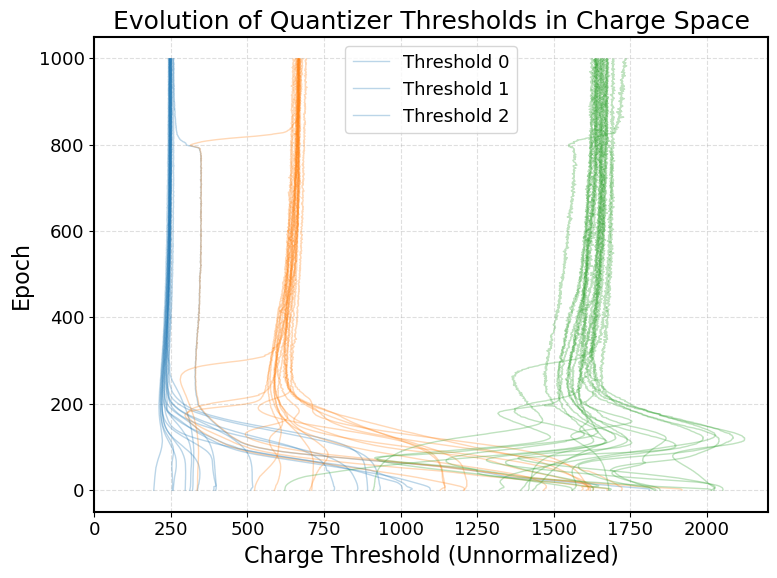

In [64]:
# --- Step 3: plot ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

plt.figure(figsize=(8, 6))
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        plt.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

plt.xlabel("Charge Threshold (Unnormalized)")
plt.ylabel("Epoch")
plt.title("Evolution of Quantizer Thresholds in Charge Space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend([f"Threshold {i}" for i in range(3)], loc="best")
plt.tight_layout()
plt.xlim([0, 2200])
plt.show()

In [65]:
plt.rcParams.update({
    "font.size": 14,           # base font size
    "axes.labelsize": 16,      # axis label font
    "axes.titlesize": 18,      # title font
    "xtick.labelsize": 13,     # x-tick labels
    "ytick.labelsize": 13,     # y-tick labels
    "legend.fontsize": 13,     # legend text
    "axes.linewidth": 1.5,     # axis thickness
    "lines.linewidth": 2.0,    # curve thickness
    "grid.alpha": 0.5,         # grid visibility
})

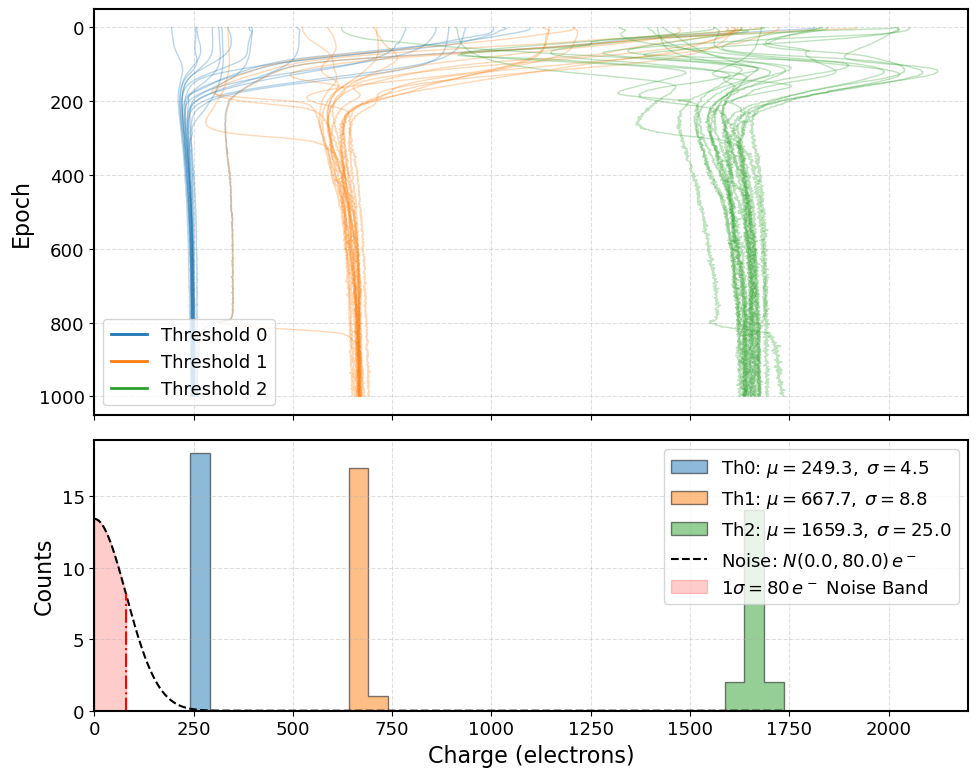

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from scipy.stats import norm

# --- Assume df_filtered already has charge_threshold_0..2 computed ---
threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

# --- Collect final thresholds per run (last epoch only) ---
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

# --- Compute histogram bins ---
all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

# --- Layout with shared x-axis ---
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

i = 0
for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

ax_evol.set_ylabel("Epoch")
# ax_evol.set_title("Evolution of Charge Thresholds + Distribution Summary")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]

ax_evol.legend(handles=handles, loc="lower left", frameon=True)


mu0, sigma0 = np.mean(raw_th0), np.std(raw_th0)
mu1, sigma1 = np.mean(raw_th1), np.std(raw_th1)
mu2, sigma2 = np.mean(raw_th2), np.std(raw_th2)

label0 = rf"Th0: $\mu={mu0:.1f},\;\sigma={sigma0:.1f}$"
label1 = rf"Th1: $\mu={mu1:.1f},\;\sigma={sigma1:.1f}$"
label2 = rf"Th2: $\mu={mu2:.1f},\;\sigma={sigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

mu_noise = NOISE_MU
sigma_noise = NOISE_SIGMA
# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
ax_hist.vlines(
    [mu_noise - sigma_noise, mu_noise + sigma_noise],
    0, pdf_val_scaled,
    color='red', linestyle='-.', linewidth=1.5
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")

plt.xlim([0, 2200])
plt.tight_layout()
plt.show()


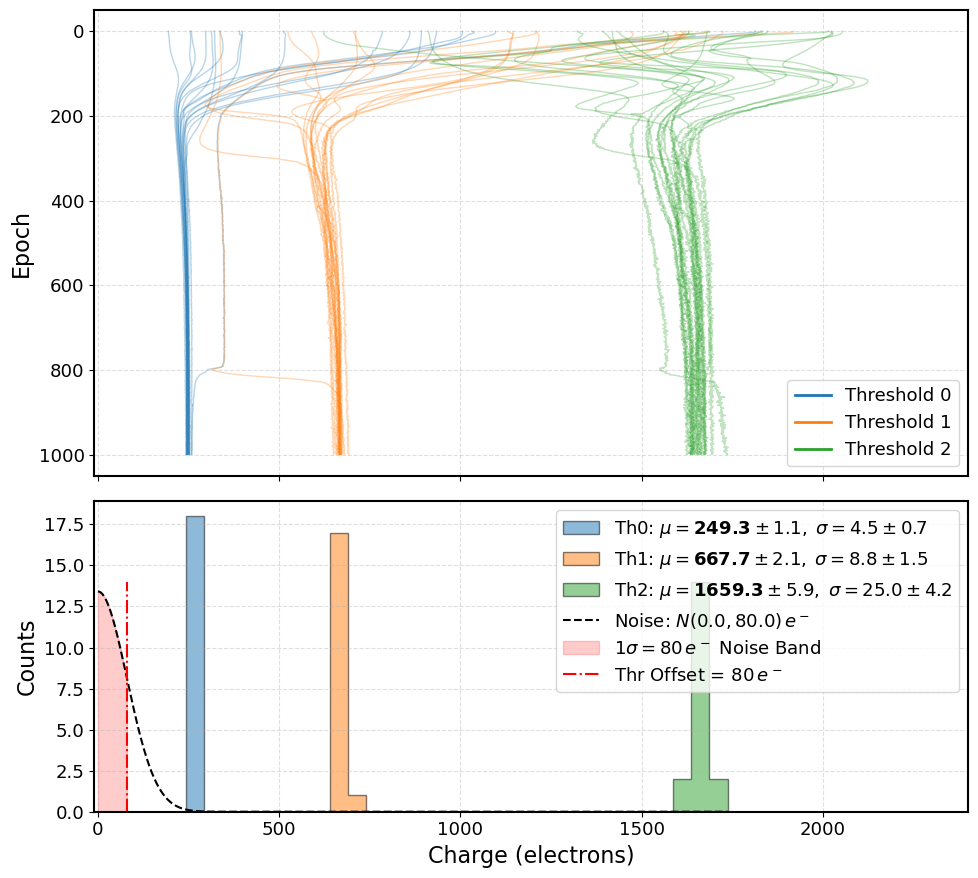

Th0: μ=249.30±1.06, σ =4.50±0.75
Th1: μ=667.66±2.08, σ =8.84±1.47
Th2: μ=1659.27±5.88, σ =24.97±4.16


In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm
from iminuit import Minuit

def gaussian_nll(x, mu, sigma):
    if sigma <= 0:
        return np.inf
    return 0.5 * np.sum(np.log(2.0 * np.pi * sigma**2) + ((x - mu) / sigma) ** 2)

def fit_gaussian_thresholds(values, label="Th"):
    x = np.asarray(values, dtype=np.float64)
    mu0, sigma0 = x.mean(), x.std(ddof=0)
    m = Minuit(lambda mu, sigma: gaussian_nll(x, mu, sigma), mu=mu0, sigma=sigma0)
    m.errordef = Minuit.LIKELIHOOD      # correct for NLL
    m.limits["sigma"] = (1e-12, None)   # keep σ > 0
    m.migrad(); m.hesse()
    mu, sigma = m.values["mu"], m.values["sigma"]
    dmu, dsigma = m.errors["mu"], m.errors["sigma"]
    return mu, sigma, dmu, dsigma
# ───────────────────────────────────────────────────────────────────

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]  # blue/orange/green

last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw_th0 = last_rows["charge_threshold_0"].to_numpy()
raw_th1 = last_rows["charge_threshold_1"].to_numpy()
raw_th2 = last_rows["charge_threshold_2"].to_numpy()

all_raw = np.concatenate([raw_th0, raw_th1, raw_th2])
bins = np.histogram_bin_edges(all_raw, bins=30)

fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(10, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)


for thr_col, color in zip(threshold_cols, colors):
    for fp in df_filtered["fingerprint"].unique():
        subset = df_filtered[df_filtered["fingerprint"] == fp]
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.3,
            linewidth=1.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.4)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color='C0', lw=2, label='Threshold 0'),
    mlines.Line2D([], [], color='C1', lw=2, label='Threshold 1'),
    mlines.Line2D([], [], color='C2', lw=2, label='Threshold 2')
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)

mu0, sigma0, dmu0, dsigma0 = fit_gaussian_thresholds(raw_th0, "Th0")
mu1, sigma1, dmu1, dsigma1 = fit_gaussian_thresholds(raw_th1, "Th1")
mu2, sigma2, dmu2, dsigma2 = fit_gaussian_thresholds(raw_th2, "Th2")

label0 = rf"Th0: $\mu=\mathbf{{{mu0:.1f}}}\pm{dmu0:.1f},\;\sigma={sigma0:.1f}\pm{dsigma0:.1f}$"
label1 = rf"Th1: $\mu=\mathbf{{{mu1:.1f}}}\pm{dmu1:.1f},\;\sigma={sigma1:.1f}\pm{dsigma1:.1f}$"
label2 = rf"Th2: $\mu=\mathbf{{{mu2:.1f}}}\pm{dmu2:.1f},\;\sigma={sigma2:.1f}\pm{dsigma2:.1f}$"

ax_hist.hist(raw_th0, bins=bins, alpha=0.5, color=colors[0],
              label=label0, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th1, bins=bins, alpha=0.5, color=colors[1],
              label=label1, histtype='stepfilled', edgecolor='black')
ax_hist.hist(raw_th2, bins=bins, alpha=0.5, color=colors[2],
              label=label2, histtype='stepfilled', edgecolor='black')

# --- Overlay noise PDF ---
x_pdf = np.linspace(0, max(bins), 1000)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf * len(all_raw) * (bins[1] - bins[0])

ax_hist.plot(
    x_pdf, pdf_scaled,
    'k--', linewidth=1.5,
    label=rf"Noise: $N({mu_noise:.1f}, {sigma_noise:.1f})\,e^-$"
)

# --- Shaded 1σ region under noise PDF ---
in_band = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_hist.fill_between(
    x_pdf, 0, pdf_scaled,
    where=in_band, color='red', alpha=0.2,
    label=rf"$1\sigma={sigma_noise:.0f}\,e^-$ Noise Band"
)

# --- Vertical lines marking ±1σ ---
pdf_val = norm.pdf(mu_noise + sigma_noise, loc=mu_noise, scale=sigma_noise)
pdf_val_scaled = pdf_val * len(all_raw) * (bins[1] - bins[0])
# ax_hist.vlines(
#     0,
#     # [mu_noise - sigma_noise, mu_noise + sigma_noise],
#     0, pdf_val_scaled,
#     color='red', linestyle='-.', linewidth=1.5, label = r"Thr Offset = $0 e^-$"
# )

ax_hist.vlines(
    x=80,
    ymin=0,
    ymax=14,
    color='red',
    linestyle='-.',
    linewidth=1.5,
    label=r"Thr Offset = $80\,e^-$"
)

ax_hist.set_xlabel("Charge (electrons)")
ax_hist.set_ylabel("Counts")
ax_hist.grid(True, linestyle="--", alpha=0.4)
ax_hist.legend(loc="upper right")
# ax_hist.set_ylim(0, 45)

plt.xlim([-10, 2400])
plt.tight_layout()
plt.show()


print(rf"Th0: μ={mu0:.2f}±{dmu0:.2f}, σ ={sigma0:.2f}±{dsigma0:.2f}")
print(rf"Th1: μ={mu1:.2f}±{dmu1:.2f}, σ ={sigma1:.2f}±{dsigma1:.2f}")
print(rf"Th2: μ={mu2:.2f}±{dmu2:.2f}, σ ={sigma2:.2f}±{dsigma2:.2f}")

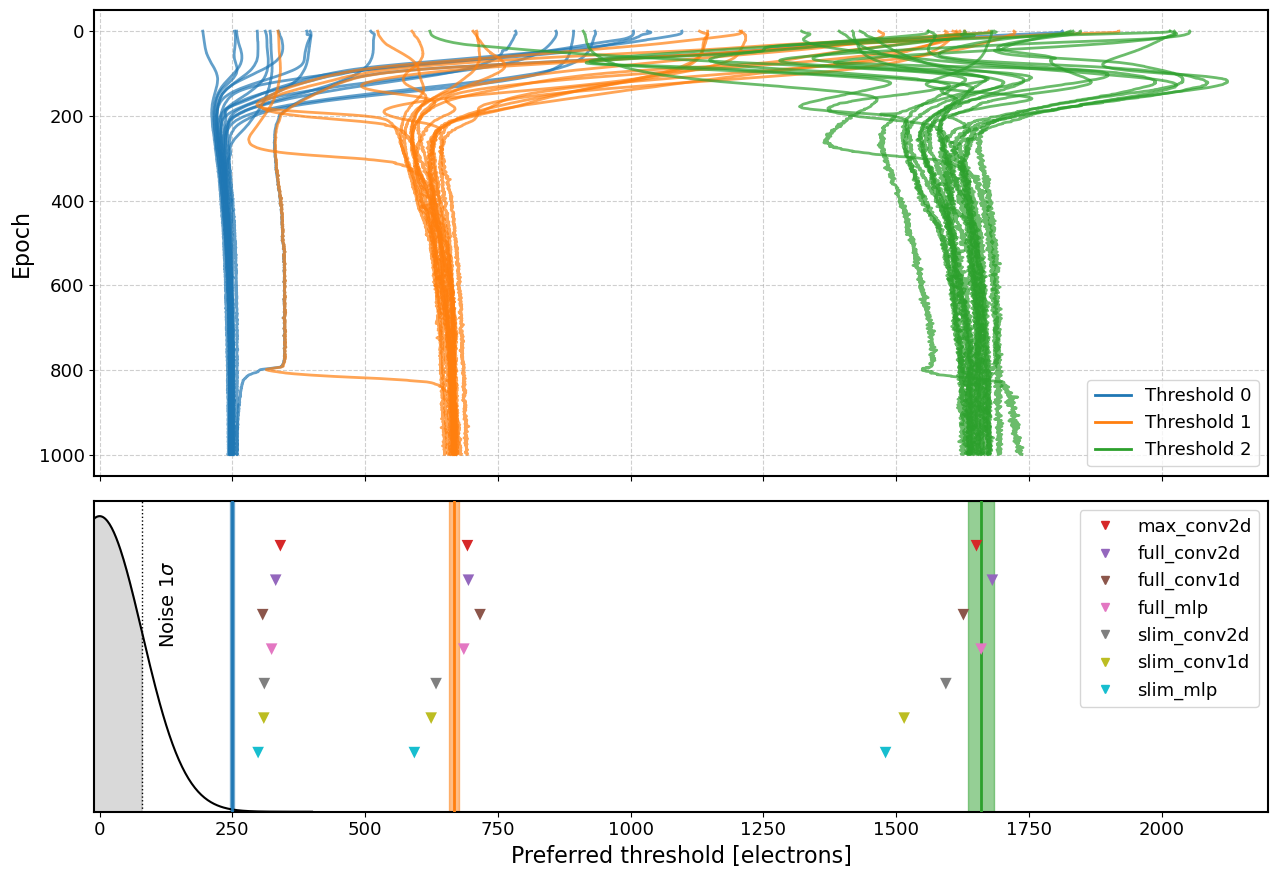

Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16


In [79]:

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw = [last_rows[c].to_numpy() for c in threshold_cols]

# exact Gaussian fits (unchanged, using your Minuit fit)
fits  = [fit_gaussian_thresholds(v, f"Th{i}") for i, v in enumerate(raw)]
mu    = np.array([f[0] for f in fits])
sigma = np.array([f[1] for f in fits])
dmu   = np.array([f[2] for f in fits])
dsig  = np.array([f[3] for f in fits])

fit_labels = [
    # rf"Th{i}: $\mu=\mathbf{{{mu[i]:.1f}}}\pm{dmu[i]:.1f},\;\sigma={sigma[i]:.1f}\pm{dsig[i]:.1f}$"
    rf"Threshold {i}"

    for i in range(3)
]

# ---------------------------------------------------------------------------
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(13, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

for thr_col, color in zip(threshold_cols, colors):
    for fp, subset in df_filtered.groupby("fingerprint"):
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.7,
            linewidth=2.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.6)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color=c, lw=2, label=fit_labels[i])
    for i, c in enumerate(colors)
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)


thresholds ={
    "max_conv2d": {
        "mu": [
            340.4,
            692.6,
            1651.1
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "full_conv2d": {
        "mu": [
            331.6,
            694.5,
            1681
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "full_conv1d": {
        "mu": [
            307.1,
            716.3,
            1626.5
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "full_mlp": {
        "mu": [
            323.9,
            685.8,
            1659.9
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "slim_conv2d": {
        "mu": [
            310.2,
            633.5,
            1593.4
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "slim_conv1d": {
        "mu": [
            309.2,
            624.3,
            1514.9
        ],
        "sigma": [
            40,
            60,
            80
        ]
    },
    "slim_mlp": {
        "mu": [
            298.5,
            592.7,
            1479.9
        ],
        "sigma": [
            40,
            60,
            80
        ]
    }
}


# ───────── bottom panel: noise curve + fitted bands + model markers ─────────
ax_pref = ax_hist
ax_pref.cla()

# noise PDF from fitted mu_noise, sigma_noise
x_pdf = np.linspace(mu_noise - 5 * sigma_noise, mu_noise + 5 * sigma_noise, 400)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf / pdf.max()

ax_pref.plot(x_pdf, pdf_scaled, "k-", linewidth=1.5)

# shaded ±1σ noise band
mask = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_pref.fill_between(x_pdf, 0, pdf_scaled, where=mask, color="k", alpha=0.15)

ax_pref.text(
    mu_noise + 1.4 * sigma_noise,
    0.7,
    r"Noise $1\sigma$",
    rotation=90,
    va="center",
    ha="left",
)

# threshold offset line (80 e-)
thr_offset = 80.0
ax_pref.axvline(thr_offset, 0.0, 1.0, color="k", linestyle=":", linewidth=1.0)

# bands from fits: outer μ±σ, inner μ±0.5σ
i = 0
for m, s in zip(mu, sigma):
    ax_pref.axvline(m, 0.0, 1.0, color=f"C{i}", zorder=3)
    ax_pref.axvspan(m - s, m + s, alpha = 0.5, color=f"C{i}", zorder=1)
    i+=1

# dummy model markers, but offsets scaled by σ (still tied to the fit)
model_names   = list(thresholds.keys())
model_colors  = ["C3","C4","C5","C6","C7", "C8", "C9", "C10"][:len(model_names)]
marker_list = ["v"]
y_levels      = np.linspace(0.9, 0.2, len(model_names))

model_handles = []

for name, color, y in zip(model_names, model_colors, y_levels):
    xvals = np.array(thresholds[name]["mu"])      # 3 μ-values per model
    yvals = np.full_like(xvals, y, dtype=float)   # same y-level

    ax_pref.scatter(
        xvals, yvals,
        marker="v", s=70,
        color=color, edgecolor="none",
        zorder=5
    )

    model_handles.append(
        mlines.Line2D([], [], color=color, marker="v", ls="none", label=name)
    )

ax_pref.set_ylim(0, 1.05)
ax_pref.set_yticks([])
ax_pref.set_xlim(-10, 2200)
ax_pref.set_xlabel("Preferred threshold [electrons]")
ax_pref.grid(False)

ax_pref.legend(
    handles=model_handles,
    loc="upper right",
    # bbox_to_anchor=(0.98, 0.5),
    frameon=True,
)

plt.tight_layout()
plt.savefig("summary-plots/Threshold_Summary.pdf", bbox_inches="tight")
plt.show()

for i in range(3):
    print(f"Th{i}: μ={mu[i]:.2f} ± {dmu[i]:.2f}, σ={sigma[i]:.2f} ± {dsig[i]:.2f}")


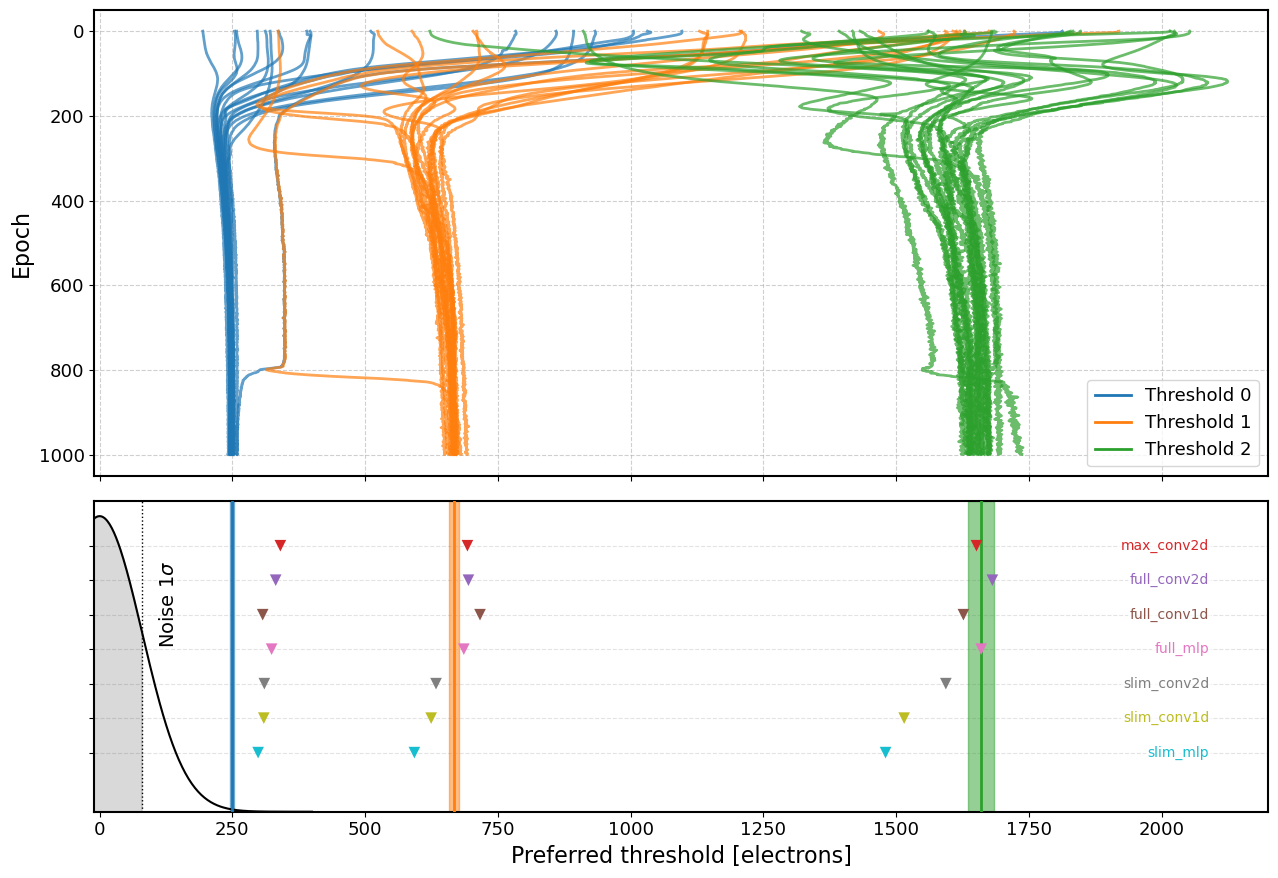

Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16


In [86]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm

# -----------------------------------------------------------------------------
# REQUIRED inputs (must already exist in your notebook/session):
#   - df_filtered : pd.DataFrame with columns:
#       ["epoch", "fingerprint", "charge_threshold_0", "charge_threshold_1", "charge_threshold_2"]
#   - mu_noise, sigma_noise : floats for your noise Gaussian
#   - fit_gaussian_thresholds(v, label) -> (mu, sigma, dmu, dsigma)
# -----------------------------------------------------------------------------

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

# last epoch per fingerprint (for the bottom-panel fit markers/bands)
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw = [last_rows[c].to_numpy() for c in threshold_cols]

# exact Gaussian fits (unchanged, using your Minuit fit)
fits  = [fit_gaussian_thresholds(v, f"Th{i}") for i, v in enumerate(raw)]
mu    = np.array([f[0] for f in fits])
sigma = np.array([f[1] for f in fits])
dmu   = np.array([f[2] for f in fits])
dsig  = np.array([f[3] for f in fits])

fit_labels = [rf"Threshold {i}" for i in range(3)]

# -----------------------------------------------------------------------------
# Figure: top panel (evolution) + bottom panel (noise + preferred thresholds)
# -----------------------------------------------------------------------------
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(13, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# ------------------------
# Top panel: evolution
# ------------------------
for thr_col, color in zip(threshold_cols, colors):
    for fp, subset in df_filtered.groupby("fingerprint"):
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.7,
            linewidth=2.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.6)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color=c, lw=2, label=fit_labels[i])
    for i, c in enumerate(colors)
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)

# ------------------------
# Bottom panel inputs
# ------------------------
thresholds = {
    "max_conv2d":  {"mu": [340.4, 692.6, 1651.1], "sigma": [40, 60, 80]},
    "full_conv2d": {"mu": [331.6, 694.5, 1681.0], "sigma": [40, 60, 80]},
    "full_conv1d": {"mu": [307.1, 716.3, 1626.5], "sigma": [40, 60, 80]},
    "full_mlp":    {"mu": [323.9, 685.8, 1659.9], "sigma": [40, 60, 80]},
    "slim_conv2d": {"mu": [310.2, 633.5, 1593.4], "sigma": [40, 60, 80]},
    "slim_conv1d": {"mu": [309.2, 624.3, 1514.9], "sigma": [40, 60, 80]},
    "slim_mlp":    {"mu": [298.5, 592.7, 1479.9], "sigma": [40, 60, 80]},
}

# ------------------------
# Bottom panel: noise curve + fitted bands + model markers
# ------------------------
ax_pref = ax_hist
ax_pref.cla()

# noise PDF from fitted mu_noise, sigma_noise
x_pdf = np.linspace(mu_noise - 5 * sigma_noise, mu_noise + 5 * sigma_noise, 400)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf / pdf.max()

ax_pref.plot(x_pdf, pdf_scaled, "k-", linewidth=1.5)

# shaded ±1σ noise band
mask = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_pref.fill_between(x_pdf, 0, pdf_scaled, where=mask, color="k", alpha=0.15)

ax_pref.text(
    mu_noise + 1.4 * sigma_noise,
    0.7,
    r"Noise $1\sigma$",
    rotation=90,
    va="center",
    ha="left",
)

# threshold offset line (80 e-)
thr_offset = 80.0
ax_pref.axvline(thr_offset, 0.0, 1.0, color="k", linestyle=":", linewidth=1.0)

# bands from fits: μ±σ
for i, (m, s) in enumerate(zip(mu, sigma)):
    ax_pref.axvline(m, 0.0, 1.0, color=f"C{i}", zorder=3)
    ax_pref.axvspan(m - s, m + s, alpha=0.5, color=f"C{i}", zorder=1)

# CHANGE: add horizontal gridlines aligned to each model row + inline model-name labels
# REASON: make it trivial to map each row of points to its model name without hunting the legend

model_names  = list(thresholds.keys())
model_colors = ["C3","C4","C5","C6","C7","C8","C9","C10"][:len(model_names)]
y_levels     = np.linspace(0.9, 0.2, len(model_names))

ax_pref.set_ylim(0, 1.05)
ax_pref.set_xlim(-10, 2200)
ax_pref.set_xlabel("Preferred threshold [electrons]")

# Put y-ticks at row centers; hide labels but use them to drive gridlines
ax_pref.set_yticks(y_levels)
ax_pref.set_yticklabels([""] * len(y_levels))
ax_pref.set_axisbelow(True)
ax_pref.grid(axis="y", linestyle="--", alpha=0.35)
ax_pref.grid(axis="x", visible=False)

# Inline labels at the left edge (x in axes fraction, y in data coords)
label_transform = ax_pref.get_yaxis_transform()

for name, color, y in zip(model_names, model_colors, y_levels):
    xvals = np.asarray(thresholds[name]["mu"], dtype=float)
    yvals = np.full_like(xvals, y, dtype=float)

    ax_pref.scatter(
        xvals, yvals,
        marker="v", s=70,
        color=color, edgecolor="none",
        zorder=5
    )

    ax_pref.text(
        0.95, y, name,
        transform=label_transform,
        va="center", ha="right",
        color=color, fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
        zorder=6
    )

# If you still want a legend, uncomment this block:
# model_handles = [
#     mlines.Line2D([], [], color=c, marker="v", ls="none", label=n)
#     for n, c in zip(model_names, model_colors)
# ]
# ax_pref.legend(handles=model_handles, loc="upper right", frameon=True)

# ------------------------
# Save + show
# ------------------------
os.makedirs("summary-plots", exist_ok=True)
plt.tight_layout()
plt.savefig("summary-plots/Threshold_Summary.pdf", bbox_inches="tight")
plt.show()

for i in range(3):
    print(f"Th{i}: μ={mu[i]:.2f} ± {dmu[i]:.2f}, σ={sigma[i]:.2f} ± {dsig[i]:.2f}")


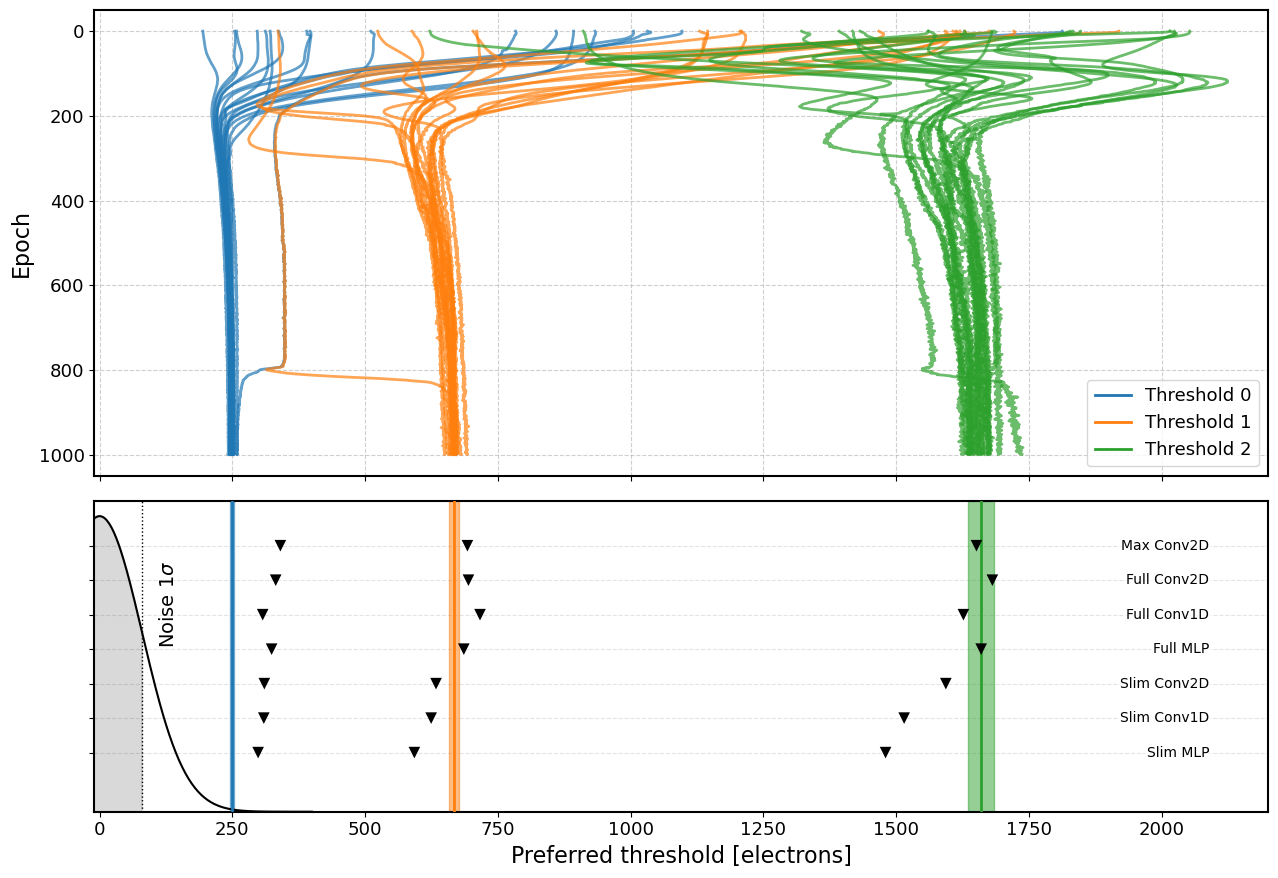

Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16


In [88]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm

# -----------------------------------------------------------------------------
# REQUIRED inputs (must already exist in your notebook/session):
#   - df_filtered : pd.DataFrame with columns:
#       ["epoch", "fingerprint", "charge_threshold_0", "charge_threshold_1", "charge_threshold_2"]
#   - mu_noise, sigma_noise : floats for your noise Gaussian
#   - fit_gaussian_thresholds(v, label) -> (mu, sigma, dmu, dsigma)
# -----------------------------------------------------------------------------

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C0", "C1", "C2"]

# last epoch per fingerprint (for the bottom-panel fit markers/bands)
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw = [last_rows[c].to_numpy() for c in threshold_cols]

# exact Gaussian fits (unchanged, using your Minuit fit)
fits  = [fit_gaussian_thresholds(v, f"Th{i}") for i, v in enumerate(raw)]
mu    = np.array([f[0] for f in fits])
sigma = np.array([f[1] for f in fits])
dmu   = np.array([f[2] for f in fits])
dsig  = np.array([f[3] for f in fits])

fit_labels = [rf"Threshold {i}" for i in range(3)]

# -----------------------------------------------------------------------------
# Figure: top panel (evolution) + bottom panel (noise + preferred thresholds)
# -----------------------------------------------------------------------------
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(13, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# ------------------------
# Top panel: evolution
# ------------------------
for thr_col, color in zip(threshold_cols, colors):
    for fp, subset in df_filtered.groupby("fingerprint"):
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.7,
            linewidth=2.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.6)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color=c, lw=2, label=fit_labels[i])
    for i, c in enumerate(colors)
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)

# ------------------------
# Bottom panel inputs
# ------------------------
thresholds = {
    "Max Conv2D":  {"mu": [340.4, 692.6, 1651.1], "sigma": [40, 60, 80]},
    "Full Conv2D": {"mu": [331.6, 694.5, 1681.0], "sigma": [40, 60, 80]},
    "Full Conv1D": {"mu": [307.1, 716.3, 1626.5], "sigma": [40, 60, 80]},
    "Full MLP":    {"mu": [323.9, 685.8, 1659.9], "sigma": [40, 60, 80]},
    "Slim Conv2D": {"mu": [310.2, 633.5, 1593.4], "sigma": [40, 60, 80]},
    "Slim Conv1D": {"mu": [309.2, 624.3, 1514.9], "sigma": [40, 60, 80]},
    "Slim MLP":    {"mu": [298.5, 592.7, 1479.9], "sigma": [40, 60, 80]},
}

# ------------------------
# Bottom panel: noise curve + fitted bands + model markers
# ------------------------
ax_pref = ax_hist
ax_pref.cla()

# noise PDF from fitted mu_noise, sigma_noise
x_pdf = np.linspace(mu_noise - 5 * sigma_noise, mu_noise + 5 * sigma_noise, 400)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf / pdf.max()

ax_pref.plot(x_pdf, pdf_scaled, "k-", linewidth=1.5)

# shaded ±1σ noise band
mask = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_pref.fill_between(x_pdf, 0, pdf_scaled, where=mask, color="k", alpha=0.15)

ax_pref.text(
    mu_noise + 1.4 * sigma_noise,
    0.7,
    r"Noise $1\sigma$",
    rotation=90,
    va="center",
    ha="left",
)

# threshold offset line (80 e-)
thr_offset = 80.0
ax_pref.axvline(thr_offset, 0.0, 1.0, color="k", linestyle=":", linewidth=1.0)

# bands from fits: μ±σ
for i, (m, s) in enumerate(zip(mu, sigma)):
    ax_pref.axvline(m, 0.0, 1.0, color=f"C{i}", zorder=3)
    ax_pref.axvspan(m - s, m + s, alpha=0.5, color=f"C{i}", zorder=1)

# CHANGE: add horizontal gridlines aligned to each model row + inline model-name labels
# REASON: make it trivial to map each row of points to its model name without hunting the legend

model_names  = list(thresholds.keys())
model_colors = ["C3","C4","C5","C6","C7","C8","C9","C10"][:len(model_names)]
y_levels     = np.linspace(0.9, 0.2, len(model_names))

ax_pref.set_ylim(0, 1.05)
ax_pref.set_xlim(-10, 2200)
ax_pref.set_xlabel("Preferred threshold [electrons]")

# Put y-ticks at row centers; hide labels but use them to drive gridlines
ax_pref.set_yticks(y_levels)
ax_pref.set_yticklabels([""] * len(y_levels))
ax_pref.set_axisbelow(True)
ax_pref.grid(axis="y", linestyle="--", alpha=0.35)
ax_pref.grid(axis="x", visible=False)

# Inline labels at the left edge (x in axes fraction, y in data coords)
label_transform = ax_pref.get_yaxis_transform()

for name, color, y in zip(model_names, model_colors, y_levels):
    xvals = np.asarray(thresholds[name]["mu"], dtype=float)
    yvals = np.full_like(xvals, y, dtype=float)

    ax_pref.scatter(
        xvals, yvals,
        marker="v", s=70,
        color='black', edgecolor="none",
        zorder=5
    )

    ax_pref.text(
        0.95, y, name,
        transform=label_transform,
        va="center", ha="right",
        color='black', fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
        zorder=6
    )

# If you still want a legend, uncomment this block:
# model_handles = [
#     mlines.Line2D([], [], color=c, marker="v", ls="none", label=n)
#     for n, c in zip(model_names, model_colors)
# ]
# ax_pref.legend(handles=model_handles, loc="upper right", frameon=True)

# ------------------------
# Save + show
# ------------------------
os.makedirs("summary-plots", exist_ok=True)
plt.tight_layout()
plt.savefig("summary-plots/Threshold_Summary.pdf", bbox_inches="tight")
plt.show()

for i in range(3):
    print(f"Th{i}: μ={mu[i]:.2f} ± {dmu[i]:.2f}, σ={sigma[i]:.2f} ± {dsig[i]:.2f}")


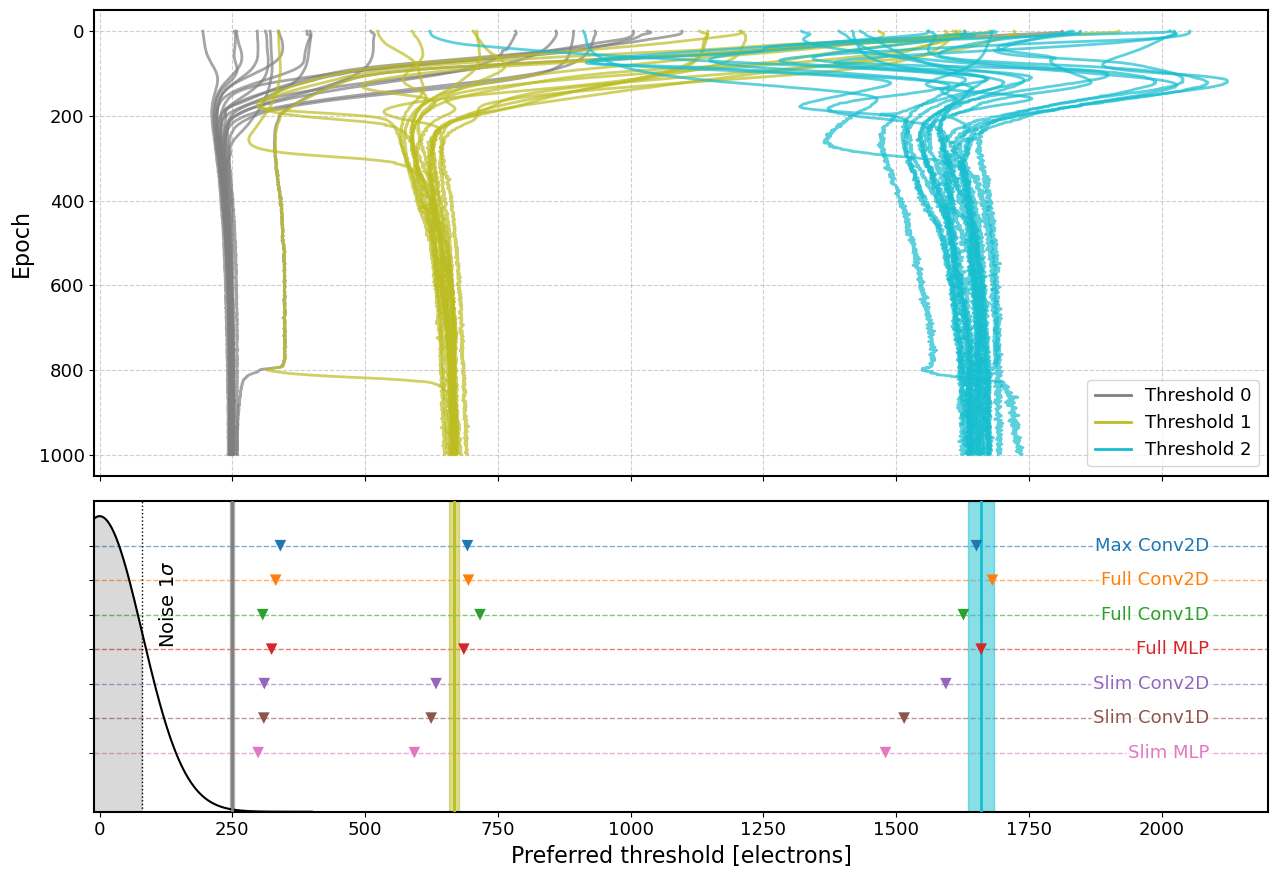

Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16


In [103]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.stats import norm

# -----------------------------------------------------------------------------
# REQUIRED inputs (must already exist in your notebook/session):
#   - df_filtered : pd.DataFrame with columns:
#       ["epoch", "fingerprint", "charge_threshold_0", "charge_threshold_1", "charge_threshold_2"]
#   - mu_noise, sigma_noise : floats for your noise Gaussian
#   - fit_gaussian_thresholds(v, label) -> (mu, sigma, dmu, dsigma)
# -----------------------------------------------------------------------------

threshold_cols = [f"charge_threshold_{i}" for i in range(3)]
colors = ["C7","C8","C9"]
th_color = colors
# last epoch per fingerprint (for the bottom-panel fit markers/bands)
last_rows = (
    df_filtered.sort_values("epoch")
    .groupby("fingerprint", as_index=False)
    .tail(1)
)

raw = [last_rows[c].to_numpy() for c in threshold_cols]

# exact Gaussian fits (unchanged, using your Minuit fit)
fits  = [fit_gaussian_thresholds(v, f"Th{i}") for i, v in enumerate(raw)]
mu    = np.array([f[0] for f in fits])
sigma = np.array([f[1] for f in fits])
dmu   = np.array([f[2] for f in fits])
dsig  = np.array([f[3] for f in fits])

fit_labels = [rf"Threshold {i}" for i in range(3)]

# -----------------------------------------------------------------------------
# Figure: top panel (evolution) + bottom panel (noise + preferred thresholds)
# -----------------------------------------------------------------------------
fig, (ax_evol, ax_hist) = plt.subplots(
    2, 1, figsize=(13, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 2]}
)

# ------------------------
# Top panel: evolution
# ------------------------
for thr_col, color in zip(threshold_cols, colors):
    for fp, subset in df_filtered.groupby("fingerprint"):
        ax_evol.plot(
            subset[thr_col],
            subset["epoch"],
            color=color,
            alpha=0.7,
            linewidth=2.0,
        )

ax_evol.set_ylabel("Epoch")
ax_evol.grid(True, linestyle="--", alpha=0.6)
ax_evol.invert_yaxis()

handles = [
    mlines.Line2D([], [], color=c, lw=2, label=fit_labels[i])
    for i, c in enumerate(th_color)
]
ax_evol.legend(handles=handles, loc="lower right", frameon=True)

# ------------------------
# Bottom panel inputs
# ------------------------
thresholds = {
    "Max Conv2D":  {"mu": [340.4, 692.6, 1651.1], "sigma": [40, 60, 80]},
    "Full Conv2D": {"mu": [331.6, 694.5, 1681.0], "sigma": [40, 60, 80]},
    "Full Conv1D": {"mu": [307.1, 716.3, 1626.5], "sigma": [40, 60, 80]},
    "Full MLP":    {"mu": [323.9, 685.8, 1659.9], "sigma": [40, 60, 80]},
    "Slim Conv2D": {"mu": [310.2, 633.5, 1593.4], "sigma": [40, 60, 80]},
    "Slim Conv1D": {"mu": [309.2, 624.3, 1514.9], "sigma": [40, 60, 80]},
    "Slim MLP":    {"mu": [298.5, 592.7, 1479.9], "sigma": [40, 60, 80]},
}

# ------------------------
# Bottom panel: noise curve + fitted bands + model markers
# ------------------------
ax_pref = ax_hist
ax_pref.cla()

# noise PDF from fitted mu_noise, sigma_noise
x_pdf = np.linspace(mu_noise - 5 * sigma_noise, mu_noise + 5 * sigma_noise, 400)
pdf = norm.pdf(x_pdf, loc=mu_noise, scale=sigma_noise)
pdf_scaled = pdf / pdf.max()

ax_pref.plot(x_pdf, pdf_scaled, "k-", linewidth=1.5)

# shaded ±1σ noise band
mask = (x_pdf >= mu_noise - sigma_noise) & (x_pdf <= mu_noise + sigma_noise)
ax_pref.fill_between(x_pdf, 0, pdf_scaled, where=mask, color="k", alpha=0.15)

ax_pref.text(
    mu_noise + 1.4 * sigma_noise,
    0.7,
    r"Noise $1\sigma$",
    rotation=90,
    va="center",
    ha="left",
)

# threshold offset line (80 e-)
thr_offset = 80.0
ax_pref.axvline(thr_offset, 0.0, 1.0, color="k", linestyle=":", linewidth=1.0)

# bands from fits: μ±σ
for i, (m, s) in enumerate(zip(mu, sigma)):
    ax_pref.axvline(m, 0.0, 1.0, color=th_color[i], zorder=3)
    ax_pref.axvspan(m - s, m + s, alpha=0.5, color=th_color[i], zorder=1)

# CHANGE: add horizontal gridlines aligned to each model row + inline model-name labels
# REASON: make it trivial to map each row of points to its model name without hunting the legend

model_names  = list(thresholds.keys())
model_colors = ["C0", "C1", "C2", "C3","C4","C5","C6"][:len(model_names)]
y_levels     = np.linspace(0.9, 0.2, len(model_names))

ax_pref.set_ylim(0, 1.05)
ax_pref.set_xlim(-10, 2200)
ax_pref.set_xlabel("Preferred threshold [electrons]")

# Put y-ticks at row centers; hide labels but use them to drive gridlines
ax_pref.set_yticks(y_levels)
ax_pref.set_yticklabels([""] * len(y_levels))
ax_pref.set_axisbelow(True)
# ax_pref.grid(axis="y", linestyle="--", alpha=0.35)
ax_pref.grid(axis="x", visible=False)

# Inline labels at the left edge (x in axes fraction, y in data coords)
label_transform = ax_pref.get_yaxis_transform()

for name, color, y in zip(model_names, model_colors, y_levels):
    xvals = np.asarray(thresholds[name]["mu"], dtype=float)
    yvals = np.full_like(xvals, y, dtype=float)

    ax_pref.scatter(
        xvals, yvals,
        marker="v", s=70,
        color=color, edgecolor="none",
        zorder=5
    )

    ax_pref.text(
        0.95, y, name,
        transform=label_transform,
        va="center", ha="right",
        color=color, fontsize=13,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1.5),
        zorder=6
    )
    
    ax_pref.axhline(y, color=color, linestyle="--", linewidth=1.0, alpha=0.6, zorder=0)


# If you still want a legend, uncomment this block:
# model_handles = [
#     mlines.Line2D([], [], color=c, marker="v", ls="none", label=n)
#     for n, c in zip(model_names, model_colors)
# ]
# ax_pref.legend(handles=model_handles, loc="upper right", frameon=True)

# ------------------------
# Save + show
# ------------------------
os.makedirs("summary-plots", exist_ok=True)
plt.tight_layout()
plt.savefig("summary-plots/Threshold_Summary.pdf", bbox_inches="tight")
plt.show()

for i in range(3):
    print(f"Th{i}: μ={mu[i]:.2f} ± {dmu[i]:.2f}, σ={sigma[i]:.2f} ± {dsig[i]:.2f}")
